In [39]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [40]:
model = "gpt2-xl"
template = "0_shot"
num_samples = 3800

# dataset = "glue/cola"
dataset = "glue/sst2"
# dataset = "glue/mrpc"
# dataset = "glue/stsb"
# dataset = "glue/qqp"
# dataset = "glue/mnli"
# dataset = "glue/qnli"
# dataset = "glue/rte"
# dataset = "glue/wnli"

# method = "baseline"
# method = "embeddings_ft_map=identity_affine_alpha=matrix_bias=True_loss=log-loss"
# method = "logits_ft_map=identity_affine_alpha=matrix_bias=True_loss=log-loss"
method = "logits_ft_map=identity_affine_alpha=vector_bias=True_loss=log-loss"
# method = "logits_ft_map=identity_affine_alpha=scalar_bias=True_loss=log-loss"
# method = "logits_ft_map=identity_affine_alpha=none_bias=True_loss=log-loss"
# method = "embeddings_ft_map=quadratic_affine_alpha=matrix_bias=True_loss=log-loss"
# method = "logits_ft_map=quadratic_affine_alpha=matrix_bias=True_loss=log-loss"
# method = "embeddings_ft_map=identity_mahalanobis"
# method = "logits_ft_map=identity_mahalanobis"
# method = "embeddings_ft_map=identity_qda"
# method = "logits_ft_map=identity_qda"
# method = "embeddings_ft_map=identity_lda"
# method = "logits_ft_map=identity_lda"

if method == "baseline":
    features_path = f"../results/run_dataset_on_model/{model}/{dataset}/validation/{template}/logits.npy"
else:
    features_path = f"../results/calibrate_features/{model}/{dataset}/{template}--{num_samples}/{method}/calibrated_posteriors.npy"
    
labels_path = f"../results/run_dataset_on_model/{model}/{dataset}/validation/{template}/labels.npy"

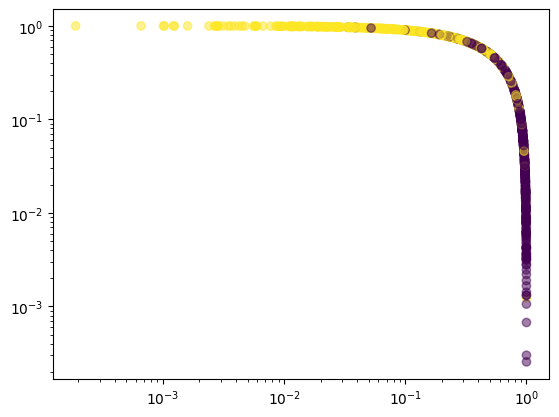

In [43]:
features = np.load(features_path)
labels = np.load(labels_path)

# Perform PCA
# pca = make_pipeline(StandardScaler(), PCA(n_components=min(3, features.shape[1])))
# pca.fit(features)
# features = pca.transform(features)
features = np.exp(features) / np.sum(np.exp(features), axis=1, keepdims=True)

# Make 3D plot with labels
if features.shape[1] == 3:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(features[:,0], features[:,1], features[:,2], c=labels, alpha=0.5)
else:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(features[:,0], features[:,1], c=labels, alpha=0.5)

ax.set_xscale('log')
ax.set_yscale('log')
plt.show()


In [42]:
features

array([[-4.6317773e+00, -9.7851856e-03],
       [-5.7599578e+00, -3.1562059e-03],
       [-1.6612314e-03, -6.4010010e+00],
       ...,
       [-6.7497359e-04, -7.3011761e+00],
       [-2.4983115e+00, -8.5801654e-02],
       [-2.2012782e-03, -6.1197968e+00]], dtype=float32)